In [ ]:
import joblib
import os
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Step 1: Initializing the SHAP Explainability Engine ---")

processed_dir = "../data/processed/"
models_dir = "../models/"

# 1. Load the AI and the Network Traffic
print("Loading Random Forest Brain and Test Matrix...")
rf_model = joblib.load(os.path.join(models_dir, "rf_model_ton_iot.joblib"))

# Load the test data (This actually still contains your real column names!)
X_test_df = joblib.load(os.path.join(processed_dir, "ton_iot_X_test.pkl"))

# 2. Sample the data using the TRUE dataframe
print("Sampling 500 network flows for Game Theory analysis...")
X_sample = shap.sample(X_test_df, 500)

# 3. Calculate Shapley Values
print("Calculating Shapley values... (Please wait)")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# SHAP API handling for binary classification
if isinstance(shap_values, list):
    shap_values_attack = shap_values[1] 
else:
    shap_values_attack = shap_values[:, :, 1] if len(np.shape(shap_values)) == 3 else shap_values

print("\n--- Step 2: Generating SENTRi-X Global Brain Visualizations ---")

# Plot 1: The Global Importance Bar Chart
plt.figure(figsize=(10, 6))
plt.title("SENTRi-X Core: Top Features Triggering Attack Alerts (ToN-IoT)")
shap.summary_plot(shap_values_attack, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Plot 2: The Feature Impact Dot Plot
plt.figure(figsize=(10, 6))
plt.title("SENTRi-X Core: Mathematical Impact of Feature Values (ToN-IoT)")
shap.summary_plot(shap_values_attack, X_sample, show=False)
plt.tight_layout()
plt.show()

--- Step 3: Local Explainability (LIME) ---
Initializing LIME Explainer...

Intercepted Attack Packet at Index: 1
Generating human-readable rule for this specific packet...


c:\Users\LENOVO\SENTRi-X\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


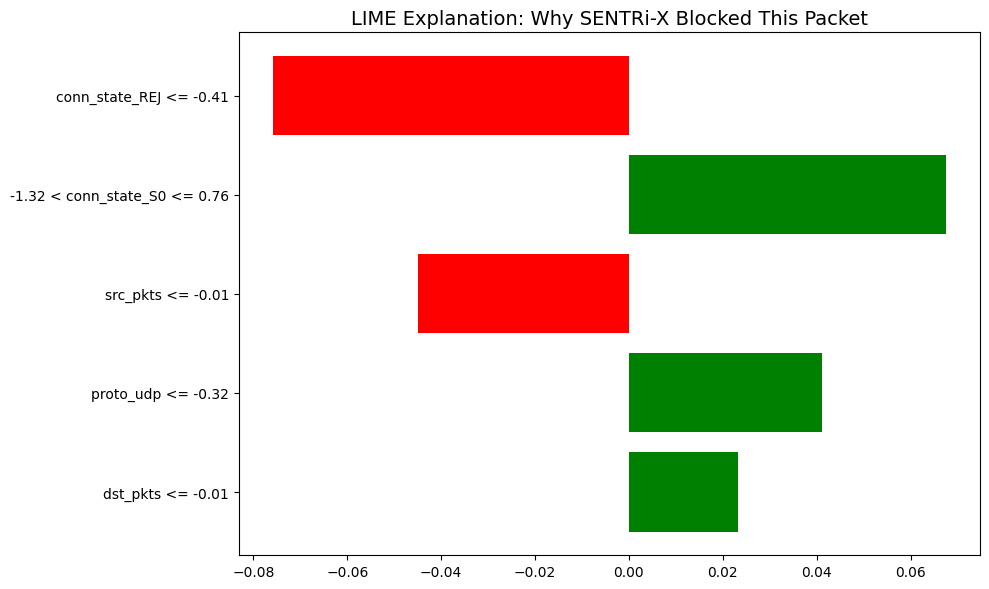


--- Exact Rules for your Manuscript Text ---
Feature Rule: [conn_state_REJ <= -0.41] -> Impact: -0.0759 (SUPPRESSES Attack Alert)
Feature Rule: [-1.32 < conn_state_S0 <= 0.76] -> Impact: 0.0676 (PROMOTES Attack Alert)
Feature Rule: [src_pkts <= -0.01] -> Impact: -0.0450 (SUPPRESSES Attack Alert)
Feature Rule: [proto_udp <= -0.32] -> Impact: 0.0411 (PROMOTES Attack Alert)
Feature Rule: [dst_pkts <= -0.01] -> Impact: 0.0233 (PROMOTES Attack Alert)


In [ ]:
import lime.lime_tabular
from IPython.display import HTML, display # <-- The modern import fix!
import numpy as np
import matplotlib.pyplot as plt

print("--- Step 3: Local Explainability (LIME) ---")
print("Initializing LIME Explainer...")

# 1. Load the answers (y_test) so we can specifically hunt down a confirmed attack
y_test = joblib.load(os.path.join(processed_dir, "ton_iot_y_test.pkl"))

# 2. Initialize the Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_df.values, 
    feature_names=X_test_df.columns.tolist(),
    class_names=['Normal (0)', 'Attack (1)'],
    mode='classification'
)

# 3. Intercept a live attack from the dataset
attack_indices = np.where(y_test == 1)[0]
sample_idx = attack_indices[0] # Grab the very first attack packet we find
packet_data = X_test_df.iloc[sample_idx]

print(f"\nIntercepted Attack Packet at Index: {sample_idx}")
print("Generating human-readable rule for this specific packet...")

# 4. Generate the explanation
lime_exp = lime_explainer.explain_instance(
    data_row=packet_data.values,
    predict_fn=rf_model.predict_proba,
    num_features=5
)

# 5. Render as a clean Matplotlib figure
fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title("LIME Explanation: Why SENTRi-X Blocked This Packet", fontsize=14)
plt.tight_layout()
plt.show()

# 6. Print the raw data cleanly so you can copy-paste it into your manuscript text
print("\n--- Exact Rules for your Manuscript Text ---")
for feature, weight in lime_exp.as_list():
    impact = "PROMOTES Attack Alert" if weight > 0 else "SUPPRESSES Attack Alert"
    print(f"Feature Rule: [{feature}] -> Impact: {weight:.4f} ({impact})")

In [ ]:
import wittgenstein as lw
import pandas as pd
import numpy as np

print("--- Step 4: Surrogate Rule Extraction (RIPPER) ---")

# 1. Sample the data (Rule extraction on 200k rows takes hours; 5000 is perfect for a surrogate)
sample_size = 5000
X_rip_sample = X_test_df.sample(n=sample_size, random_state=42)

# 2. Extract the AI's actual predictions to reverse-engineer its logic
print("Intercepting Random Forest predictions...")
y_rip_pred = rf_model.predict(X_rip_sample)

# 3. Initialize and Train the RIPPER Algorithm
print("Training RIPPER surrogate model to extract global IF/THEN rules... (Please wait)")
ripper_clf = lw.RIPPER()

# We pass the column names so the output is in English, not just index numbers
ripper_clf.fit(X_rip_sample, y_rip_pred, feature_names=X_test_df.columns.tolist())

print("\n--- SENTRi-X Global Rule Extraction (Snort-Equivalent Rules) ---")
print("How to read this: If [Condition A] AND [Condition B] --> Then ATTACK")
print("-" * 60)

# 4. Output the exact human-readable ruleset
ripper_clf.out_model()

--- Step 4: Surrogate Rule Extraction (RIPPER) ---


NameError: name 'X_test_df' is not defined